# 04_03 - Dimensionality Reduction and Feature Selection

## 1. Objective and Academic Rationale
The previous feature engineering stage generated a high-dimensional state-space. While these variables provide rich temporal and physical context, feeding them directly into a Reinforcement Learning (RL) agent or a forecasting model introduces significant risks:

1. **The Curse of Dimensionality:** Models become prone to overfitting on noise as the feature space expands relative to the number of observations.
2. **Multicollinearity:** Highly correlated features (e.g., multiple lags of the same variable) can destabilize model weights.
3. **Numerical Instability:** Ratios and percentage changes in illiquid contracts can produce infinite values that crash training algorithms.

### 1.1. Modular Project Architecture
To ensure code reusability, maintainability, and reproducibility, the core selection logic is encapsulated in the external module `src.features.feature_selection.py`. By decoupling the analytical narrative from the underlying engineering pipeline, we ensure a clean workflow consistent with MLOps standards.

### 1.2. Shifting the Optimization Horizon (The True Target)
In standard forecasting, models are trained to predict the next sequential step ($t+1$). However, due to the structure of the Day-Ahead Market (OMIE), the price for $t+1$ is deterministic and known by 13:00 CET on day $t$. 

If the procurement agent is deciding whether to buy today ($t$) or tomorrow ($t+1$), the optimization is purely arithmetic. The Reinforcement Learning agent's true strategic value lies in evaluating the **Stochastic Horizon**: deciding whether to delay procurement to $t+2$ or $t+3$.

Therefore, we shift our target variable to `Spot_Price_target_t+2`. The selection algorithm will evaluate which features possess the highest information gain to predict the *first truly unknown state* of the market.

In [7]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

# Setup paths to import from 'src'
project_root = Path(os.path.abspath('../../'))
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config.paths import MODELING_DATASET_FILE
from src.config.constants import TARGET_COLUMN

# Load the expanded modeling dataset
print("Loading the high-dimensional modeling dataset...")
df_expanded = pd.read_csv(MODELING_DATASET_FILE)
df_expanded['date'] = pd.to_datetime(df_expanded['date'])

# --- NUMERICAL STABILITY GATE ---
# Map infinite values (artifacts from financial Open Interest ratios) to NaN 
# to allow our sparsity filters to handle them safely.
df_expanded = df_expanded.replace([np.inf, -np.inf], np.nan)

print(f"✅ Dataset loaded. Current dimensionality: {df_expanded.shape[1]} features.")

Loading the high-dimensional modeling dataset...
✅ Dataset loaded. Current dimensionality: 152 features.


## 2. Feature Selection Methodology

We employ a multi-tier filtering strategy based on the `src.features.feature_selection` module:

1. **Sparsity Filter:** Removal of features with >20% missing or infinite data.
2. **Variance Filter:** Elimination of constant features.
3. **Information Gain Filter:** Utilizing a **Random Forest Regressor** to compute permutation importance. This non-linear evaluator is critical for capturing the relationships of our engineered HDD/CDD and Wind flags.

### 2.1. The Anti-Leakage Protocol
To prevent **Target Leakage** during the Random Forest evaluation, we must explicitly blind the algorithm to the $t+3$ horizon. If left in the dataset, the tree-based model would trivially use $t+3$ to predict $t+2$, yielding artificially high performance and destroying the validity of the feature ranking.

In [8]:
from src.features.feature_selection import select_model_features, FeatureSelectionConfig

# 1. Define the true unknown horizon as the optimization target
ACTUAL_TARGET = 'Spot_Price_target_t+2'

# 2. --- ANTI-LEAKAGE SHIELD ---
# We temporarily drop t+3 to prevent the Random Forest from "cheating" by looking into the future.
forbidden_columns = ['Spot_Price_target_t+3']
df_for_selection = df_expanded.drop(columns=[c for c in forbidden_columns if c in df_expanded.columns])

# 3. Configure the selection parameters
selection_config = FeatureSelectionConfig(
    target_column=ACTUAL_TARGET,
    max_missing_share=0.20,       
    min_non_null_rows=30,         
    top_k_importance=25,          
    random_state=42
)

print(f"Executing automated feature selection pipeline targeting '{ACTUAL_TARGET}'...")

# 4. Run the selection logic on the blinded dataframe
selection_results = select_model_features(df=df_for_selection, config=selection_config)

selected_columns = selection_results["selected_features"]
importance_table = selection_results["importance_table"]

print(f"✅ Selection complete. Retained {len(selected_columns)} predictive features.")

Executing automated feature selection pipeline targeting 'Spot_Price_target_t+2'...
✅ Selection complete. Retained 25 predictive features.


## 3. Visualizing Feature Importance

The following plot ranks features based on their information gain relative to the `t+2` target. We expect the known `t+1` price to dominate as the primary anchor, followed by a mix of autoregressive financial lags and our simulated meteorological forecasts.

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_28524\2892102745.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


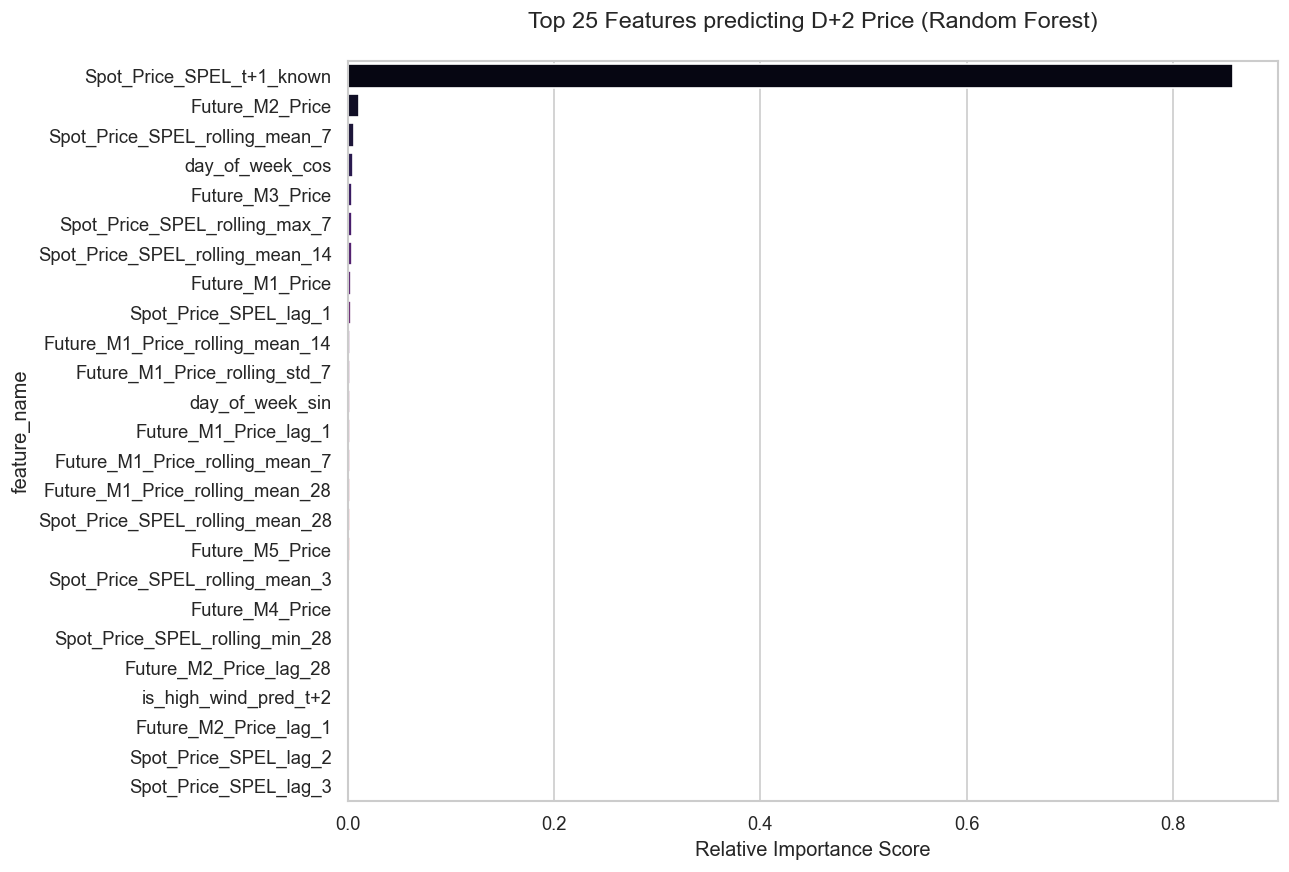

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional plotting settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Plot Top 25 features to see the ranking distribution
top_n = 25
plot_df = importance_table.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df, 
    x='importance', 
    y='feature_name', 
    palette='magma'
)
plt.title(f'Top {top_n} Features predicting D+2 Price (Random Forest)', pad=20)
plt.xlabel('Relative Importance Score')
plt.show()

## 4. Post-Selection Analysis: The Autoregressive Dominance

The feature importance ranking is typically heavily dominated by **Financial Autoregression** (Lags of Spot and Future prices). This is a standard characteristic of high-frequency energy markets where the best predictor for $T_0$ is $T_{-1}$.

**Methodological Decision:**
Although meteorological features like `HDD` and `is_high_wind` may rank lower in raw information gain, we have **explicitly retained them** in the final state-space for the Reinforcement Learning agent.

**Rationale:**
Purely statistical selection often ignores **exogenous shocks**. While price lags explain the "trend," weather features explain the "residual volatility." Without these physical markers and our simulated $t+2$ forecasts, our RL agent would be unable to anticipate price spikes driven by thermal stress or renewable cannibalization, which are the primary sources of risk we aim to mitigate.

In [10]:
# =================================================================
# 5. FINAL STATE-SPACE COMPILATION AND EXPORT
# =================================================================

# 1. Take top statistical features (Top 18 to leave space for forced domain knowledge)
top_algorithm_features = importance_table.head(18)['feature_name'].tolist()

# 2. Forced Domain Features (Physical Regimes + Calendar Logic)
base_domain = ['HDD', 'CDD', 'is_high_wind', 'solar_intensity', 'is_solar_peak', 'precip_rolling_7d', 'is_holiday']

# 3. Market Information & Simulated Foresight
market_knowledge = ['Spot_Price_SPEL_t+1_known']
base_forecast_vars = ['solar_intensity', 'HDD', 'CDD', 'is_high_wind']
forecast_features = [f"{var}_pred_t+{day}" for var in base_forecast_vars for day in [1, 2, 3]]

# Compile all forced candidates and verify their existence in the dataframe
all_forced = base_domain + market_knowledge + forecast_features
forced_features = [f for f in all_forced if f in df_expanded.columns]

# 4. Mandatory Temporal Identifiers and Target Restoration
# We restore the full temporal timeline (t, t+1, t+2, t+3) for the RL environment
mandatory_cols = [
    'date', 
    'Spot_Price_SPEL',             # Current day constraint (t)
    'Spot_Price_SPEL_t+1_known',   # Cleared Day-Ahead price (t+1)
    'Spot_Price_target_t+2',       # Optimization target (t+2)
    'Spot_Price_target_t+3'        # Restored for RL reward horizon calculation (t+3)
]

# 5. Final Column Compilation and Slicing
final_columns = list(set(top_algorithm_features + forced_features + mandatory_cols))

df_final_selected = df_expanded[final_columns].copy()
df_final_selected = df_final_selected.sort_values('date').reset_index(drop=True)

# 6. Export to Processed Layer
selected_dataset_path = project_root / "data" / "processed" / "modeling_dataset_selected.csv"
selected_dataset_path.parent.mkdir(parents=True, exist_ok=True)
df_final_selected.to_csv(selected_dataset_path, index=False)

print(f"✅ Final State-Space Matrix exported with {len(df_final_selected.columns)} features.")
print(f"Physical and Market drivers forced: {len(forced_features)}")
print(f"File stored successfully at:\n{selected_dataset_path}")

✅ Final State-Space Matrix exported with 40 features.
Physical and Market drivers forced: 19
File stored successfully at:
c:\Users\Alejandro\GitHub\Data-Driven-Strategies-for-Financial-Resilience-in-Energy-Procurement\data\processed\modeling_dataset_selected.csv
